In [9]:
nav = pd.read_csv('../data/02_nav_history.csv')
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [10]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [11]:
# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Sort data
nav = nav.sort_values(['amfi_code', 'date'])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [12]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [13]:
nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


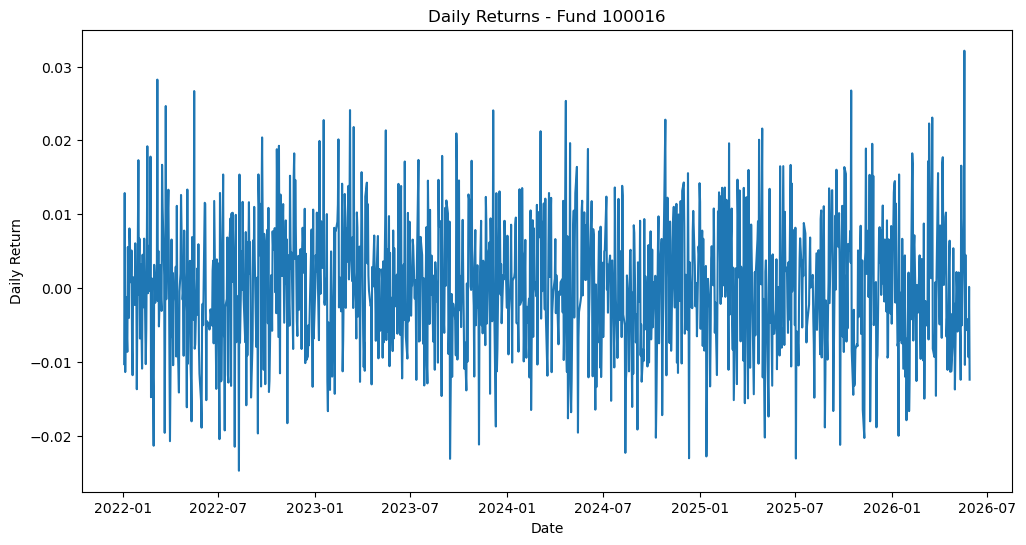

In [14]:
sample_fund = nav['amfi_code'].iloc[0]

temp = nav[nav['amfi_code'] == sample_fund]

plt.figure(figsize=(12,6))
plt.plot(temp['date'], temp['daily_return'])
plt.title(f'Daily Returns - Fund {sample_fund}')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

In [15]:
performance = nav.groupby('amfi_code')['daily_return'].agg([
    'mean',
    'std',
    'min',
    'max'
]).reset_index()

performance.columns = [
    'amfi_code',
    'avg_daily_return',
    'volatility',
    'min_return',
    'max_return'
]

performance.head()

,amfi_code,avg_daily_return,volatility,min_return,max_return
0,100016,0.000142,0.009164,-0.024744,0.032145
1,100025,0.000170,0.002460,-0.008188,0.008837
2,100033,0.001080,0.011929,-0.044238,0.041954
3,101206,0.000852,0.009177,-0.038121,0.033956
4,101207,0.000424,0.016251,-0.051847,0.054851


In [16]:
performance['sharpe_ratio'] = (
    performance['avg_daily_return'] /
    performance['volatility']
)

performance.head()

,amfi_code,avg_daily_return,volatility,min_return,max_return,sharpe_ratio
0,100016,0.000142,0.009164,-0.024744,0.032145,0.015451
1,100025,0.000170,0.002460,-0.008188,0.008837,0.069125
2,100033,0.001080,0.011929,-0.044238,0.041954,0.090519
3,101206,0.000852,0.009177,-0.038121,0.033956,0.092815
4,101207,0.000424,0.016251,-0.051847,0.054851,0.026119


In [17]:
top10 = performance.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

top10

,amfi_code,avg_daily_return,volatility,min_return,max_return,sharpe_ratio
27,120507,0.000268,0.000311,-0.000666,0.001197,0.860244
31,120844,0.000256,0.000323,-0.000704,0.001254,0.792087
5,101208,0.000242,0.000319,-0.000766,0.001247,0.757138
34,148567,0.001074,0.008941,-0.029451,0.030025,0.120082
30,120843,0.001082,0.010008,-0.029748,0.033554,0.108091
19,119551,0.000917,0.008656,-0.027680,0.035096,0.105911
36,148569,0.001124,0.011134,-0.031266,0.039176,0.100961
9,118632,0.000865,0.008913,-0.028490,0.028218,0.097079
25,120505,0.001161,0.012152,-0.038418,0.040812,0.095565
38,149323,0.001055,0.011179,-0.030092,0.041995,0.094390


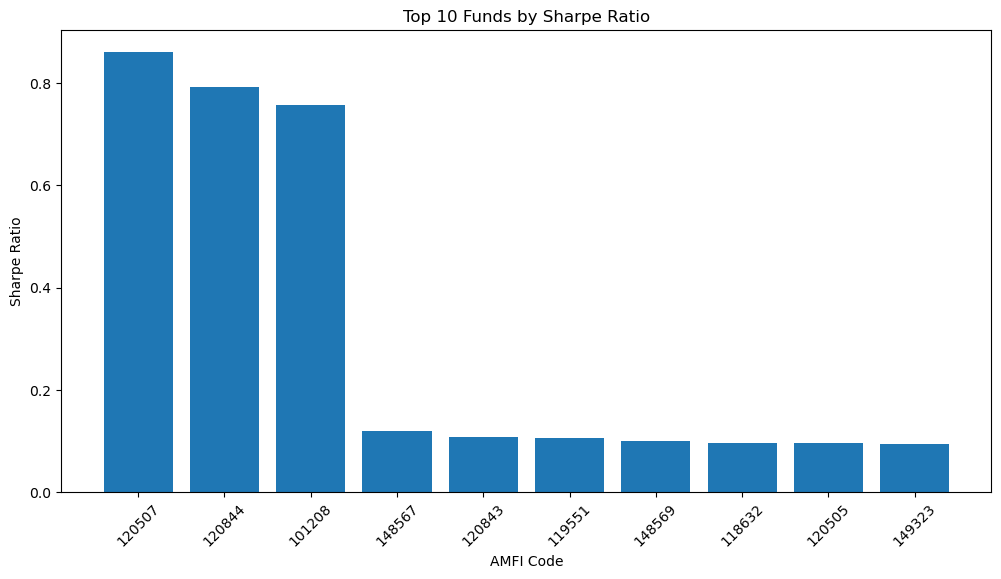

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['amfi_code'].astype(str),
    top10['sharpe_ratio']
)

plt.title('Top 10 Funds by Sharpe Ratio')
plt.xlabel('AMFI Code')
plt.ylabel('Sharpe Ratio')
plt.xticks(rotation=45)

plt.show()

In [19]:
top10.round(4)

,amfi_code,avg_daily_return,volatility,min_return,max_return,sharpe_ratio
27,120507,0.0003,0.0003,-0.0007,0.0012,0.8602
31,120844,0.0003,0.0003,-0.0007,0.0013,0.7921
5,101208,0.0002,0.0003,-0.0008,0.0012,0.7571
34,148567,0.0011,0.0089,-0.0295,0.0300,0.1201
30,120843,0.0011,0.0100,-0.0297,0.0336,0.1081
19,119551,0.0009,0.0087,-0.0277,0.0351,0.1059
36,148569,0.0011,0.0111,-0.0313,0.0392,0.1010
9,118632,0.0009,0.0089,-0.0285,0.0282,0.0971
25,120505,0.0012,0.0122,-0.0384,0.0408,0.0956
38,149323,0.0011,0.0112,-0.0301,0.0420,0.0944


In [21]:
top10.to_csv('../data/top10_funds_sharpe.csv', index=False)

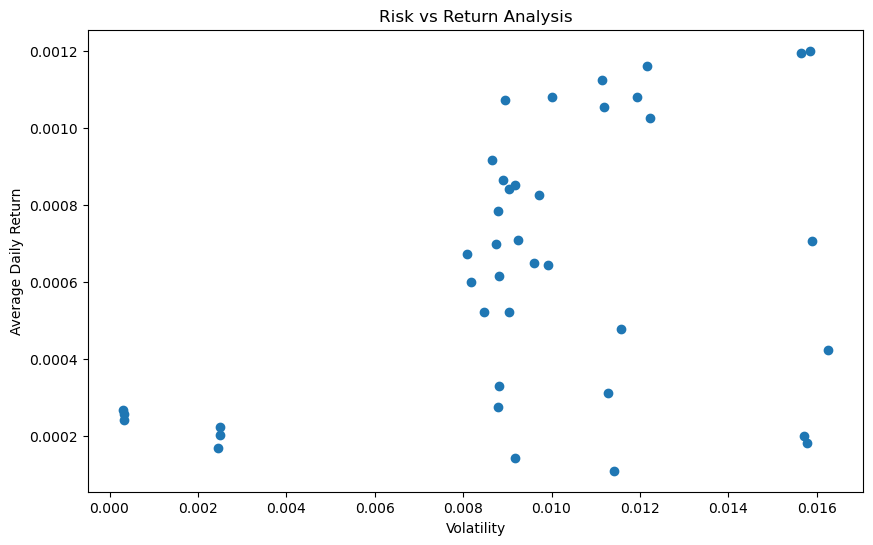

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(
    performance['volatility'],
    performance['avg_daily_return']
)

plt.title('Risk vs Return Analysis')
plt.xlabel('Volatility')
plt.ylabel('Average Daily Return')

plt.show()

## Conclusion

- Calculated daily returns for all funds.
- Evaluated volatility and Sharpe ratio.
- Identified top-performing funds.
- Visualized risk-return relationships.
- Generated fund performance analytics for investment evaluation.